# Superstore Exploratory Data Analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline
import seaborn as sns
import scipy.stats as st
from datetime import datetime

In [60]:
df = pd.read_csv("Superstore.csv" , encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [61]:
print(f'columns = {df.shape[1]}, rows = {df.shape[0]}')

columns = 21, rows = 9994


In [62]:
print(df.isna().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [63]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [64]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [65]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


In [66]:
df.describe(include='object')

,Order ID,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name
count,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994
unique,5009,4,793,793,3,1,531,49,4,1862,3,17,1850
top,CA-2017-100111,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope
freq,14,5968,37,37,5191,9994,915,2001,3203,19,6026,1523,48


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [68]:
df.corr(numeric_only=True)

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
Row ID,1.000000,0.009671,-0.001359,-0.004016,0.013480,0.012497
Postal Code,0.009671,1.000000,-0.023854,0.012761,0.058443,-0.029961
Sales,-0.001359,-0.023854,1.000000,0.200795,-0.028190,0.479064
Quantity,-0.004016,0.012761,0.200795,1.000000,0.008623,0.066253
Discount,0.013480,0.058443,-0.028190,0.008623,1.000000,-0.219487
Profit,0.012497,-0.029961,0.479064,0.066253,-0.219487,1.000000


<Axes: >

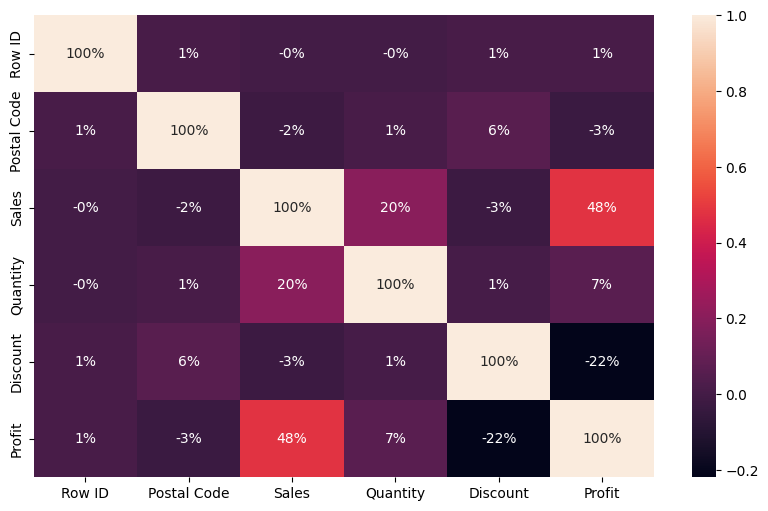

In [69]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,fmt='.0%')

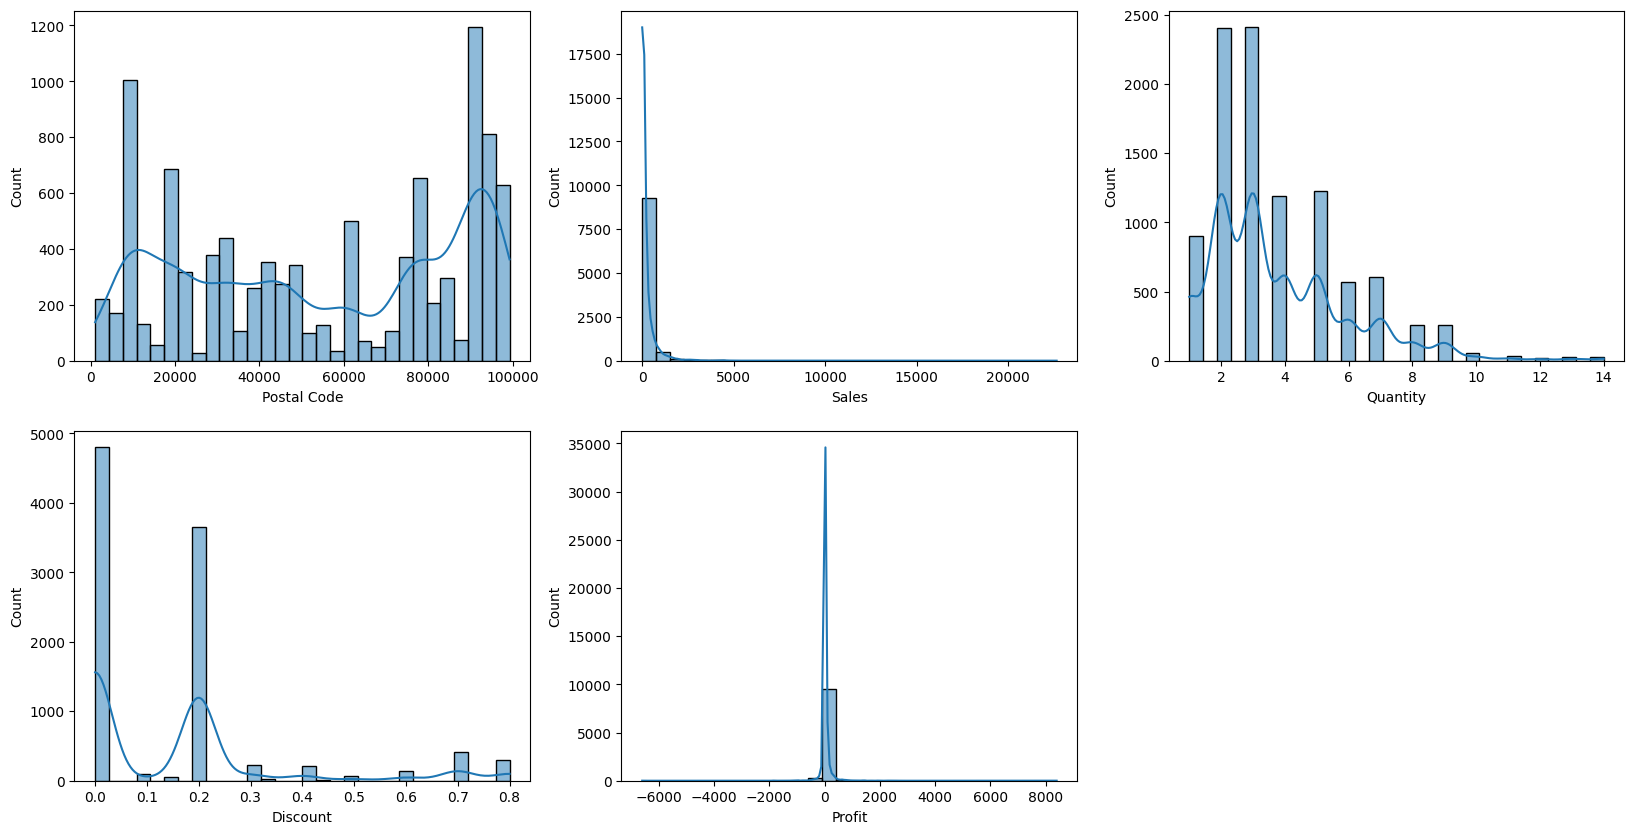

In [70]:
num_feature=['Postal Code',	'Sales', 'Quantity', 'Discount', 'Profit']

plt.figure(figsize=(20,10))
i=1
for feature in num_feature:
    plt.subplot(2,3,i)
    sns.histplot(df[feature],bins=30,kde=True)
    plt.xlabel(feature)
    i=i+1

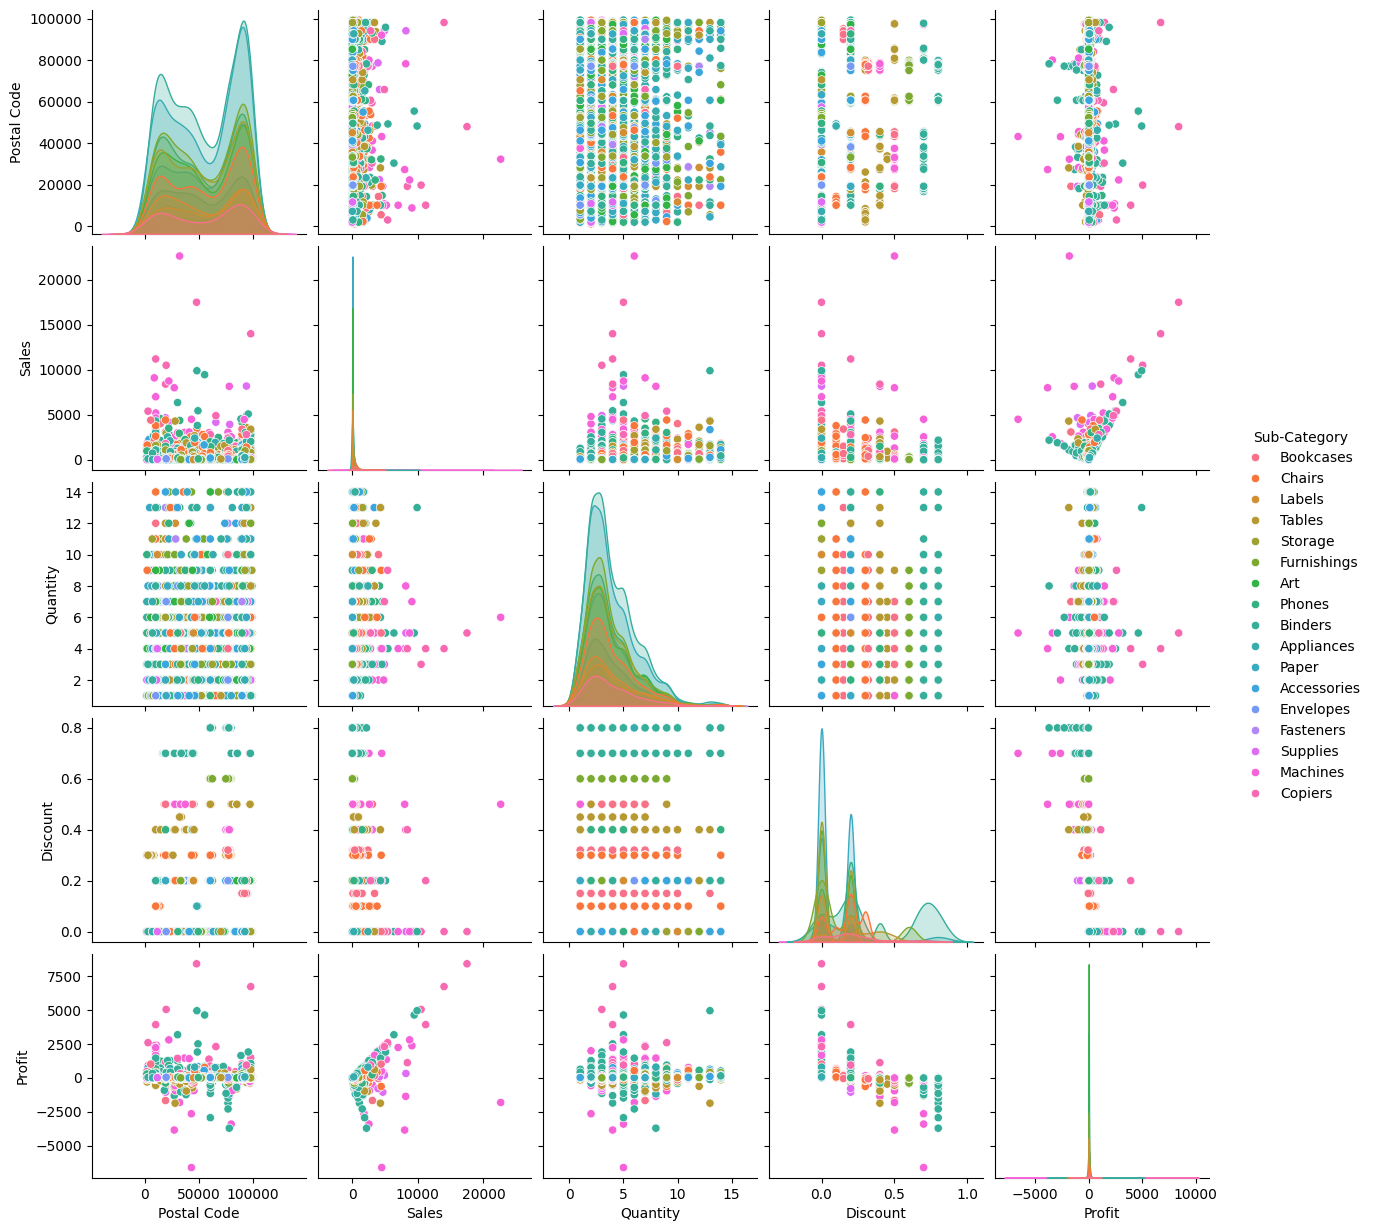

In [71]:
sns.pairplot(vars=['Postal Code', 'Sales', 'Quantity', 'Discount', 'Profit'],hue="Sub-Category",data=df)

In [72]:
market=df.groupby("Region")[["Sales","Profit","Quantity", 'Discount']].sum()
market.sort_values(by=["Profit"],ascending=False)

,Sales,Profit,Quantity,Discount
Region,,,,
West,725457.8245,108418.4489,12266,350.20
East,678781.2400,91522.7800,10618,414.00
South,391721.9050,46749.4303,6209,238.55
Central,501239.8908,39706.3625,8780,558.34


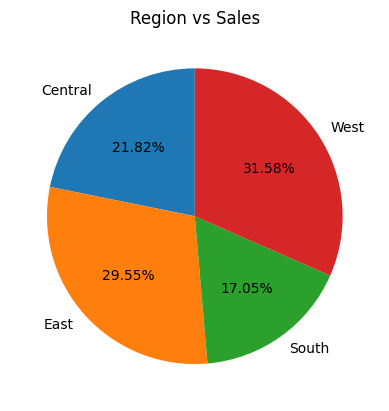

In [73]:
plt.pie(market["Sales"],labels=market.index,startangle=90,autopct='%1.2f%%')
plt.title("Region vs Sales")
plt.show()

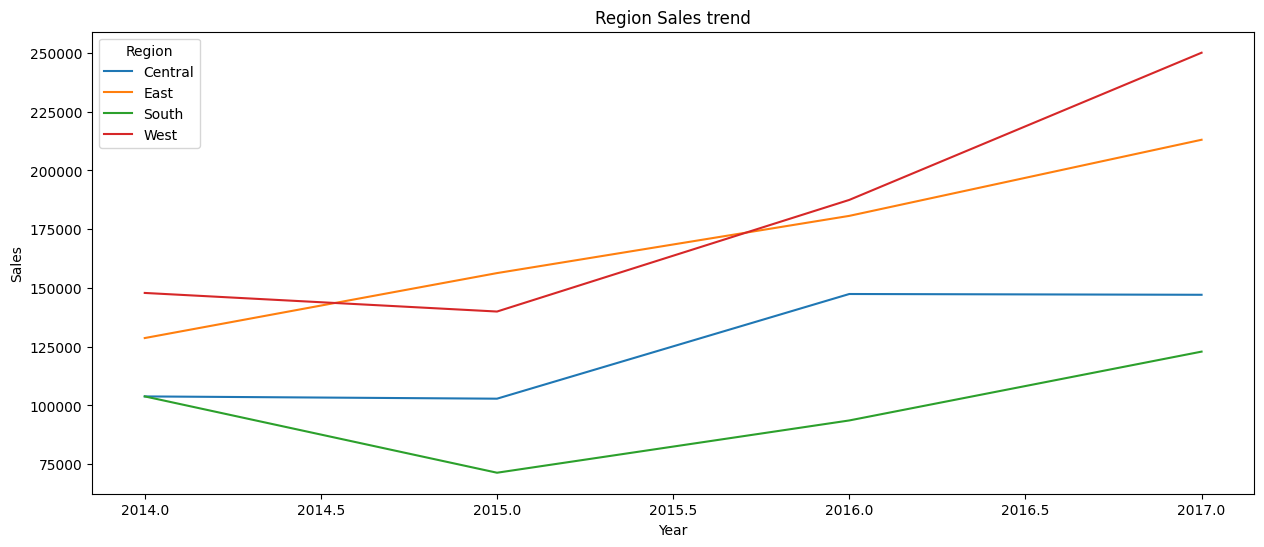

In [74]:
df["Year"]=df["Order Date"].dt.year
df.pivot_table(index="Year",columns="Region",values="Sales",aggfunc="sum").plot(kind="line",figsize=(15,6))
plt.title("Region Sales trend")
plt.ylabel("Sales")
plt.show()

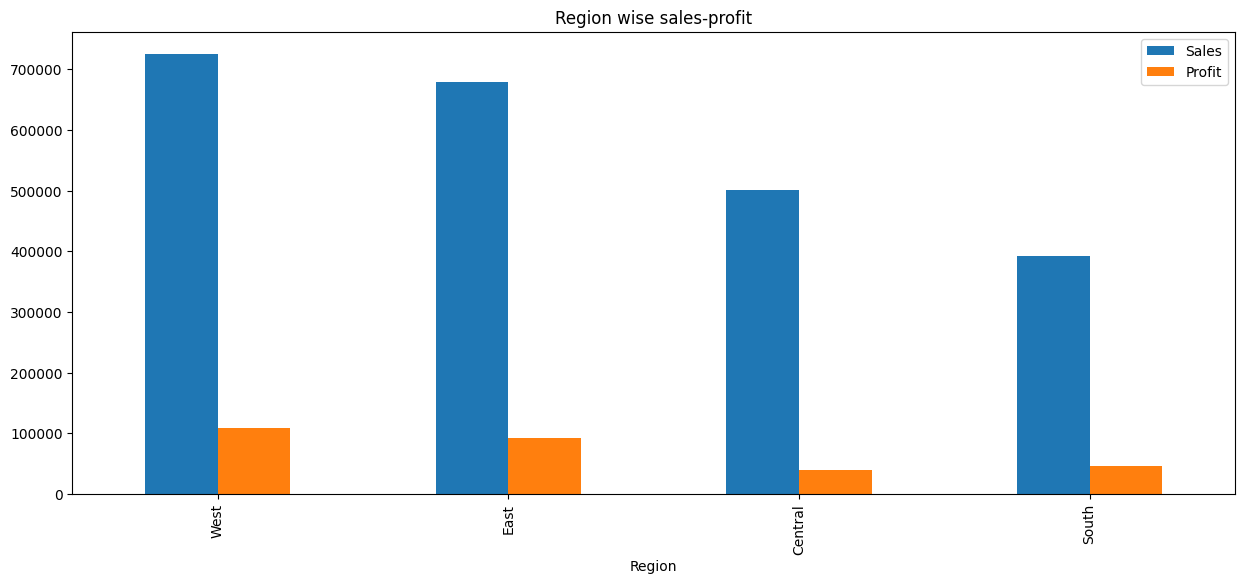

In [77]:
region=df.groupby("Region")[["Sales","Profit","Quantity"]].sum()
region[["Sales","Profit"]].sort_values(by=["Sales"],ascending=False).plot.bar(figsize=(15,6))
plt.xticks(rotation=90)
plt.title("Region wise sales-profit")
plt.show()

In [78]:
state=df.groupby("State")[['Sales','Profit',"Quantity"]].sum().sort_values(by=["Profit"],ascending=False)
state.head()

,Sales,Profit,Quantity
State,,,
California,457687.6315,76381.3871,7667
New York,310876.2710,74038.5486,4224
Washington,138641.2700,33402.6517,1883
Michigan,76269.6140,24463.1876,946
Virginia,70636.7200,18597.9504,893


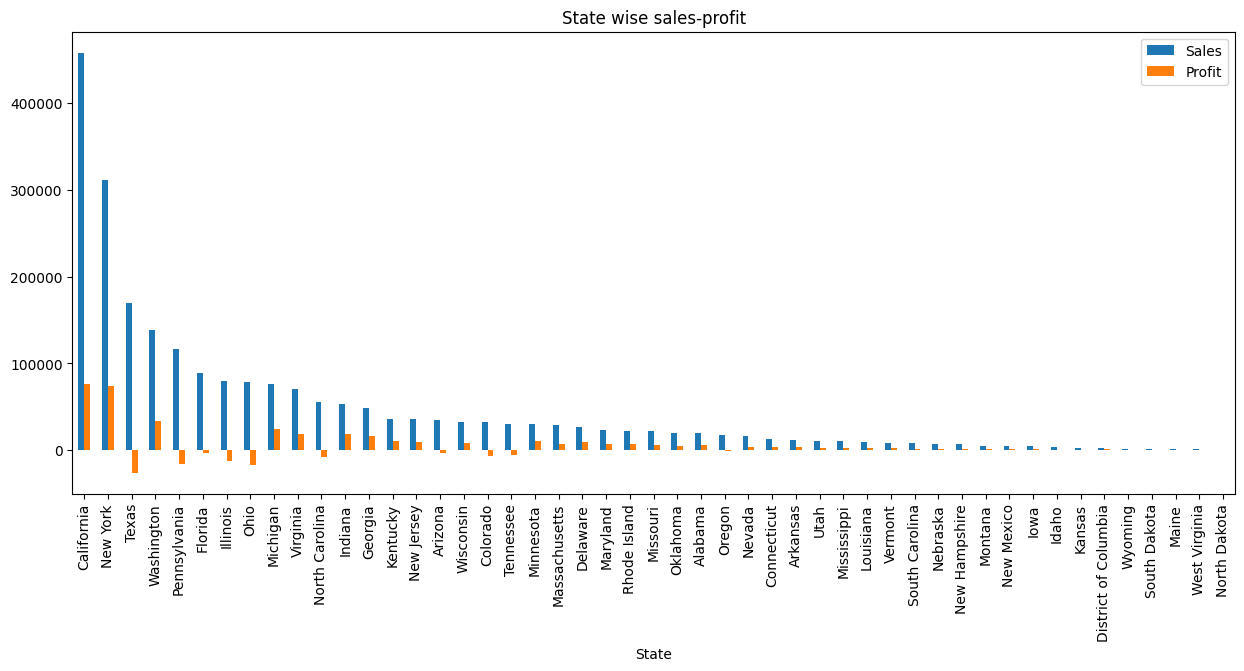

In [79]:
region=df.groupby("State")[["Sales","Profit","Quantity"]].sum()
region[["Sales","Profit"]].sort_values(by=["Sales"],ascending=False).plot.bar(figsize=(15,6))
plt.xticks(rotation=90)
plt.title("State wise sales-profit")
plt.show()

In [ ]:
df.pivot_table(index="State",columns="Year",values=["Sales","Profit"],aggfunc="sum")

Profit                                      \
Year                        2014        2015        2016        2017   
State                                                                  
Alabama                1250.7324   1199.7854   2839.9304    496.3771   
Arizona                -903.1981    236.3835  -1485.1075  -1276.0025   
Arkansas               2031.6858    103.0064    914.5922    959.4027   
California            12637.9491  14371.2630  20005.7161  29366.4589   
Colorado                438.1889  -1141.0659  -1389.1326  -4435.8483   
Connecticut             745.3332    427.1451    859.2519   1479.7616   
Delaware               1338.5933   1608.8708    976.7058   6053.2049   
District of Columbia         NaN    974.3135     50.2118     35.0640   
Florida               -1412.7599  -1758.7953   -471.8731    244.1266   
Georgia                1491.7121   4763.9147   3546.4346   6447.9819   
Idaho                    62.0510    285.3170    280.3465    199.0086   
Illinois              -2043.7367  -1009.4964  -2809.0939  -6745.5600   
Indiana                 868.1476   1990.1291  10385.1339   5139.5257   
Iowa                    109.5012    490.3654    308.0815    275.8638   
Kansas                  266.1984     76.0345    230.8462    263.3644   
Kentucky               2309.3975   2921.9151   1216.6626   4751.7214   
Louisiana               606.8026    288.1276     88.2680   1212.9041   
Maine                   256.9266     32.2658    165.2938         NaN   
Maryland                484.9964   2713.8319   1051.7435   2780.6070   
Massachusetts          2060.9684   1955.6685   1058.2778   1710.5869   
Michigan               1817.1087   5165.7983   8992.5188   8487.7618   
Minnesota              6237.3607   1721.4784    404.4694   2459.8789   
Mississippi             545.5312    123.2032   1475.6798   1028.5620   
Missouri                444.2582   2892.6640   1365.8578   1733.4305   
Montana                 129.8492    237.5538         NaN   1465.9255   
Nebraska                 58.1679    203.4658    854.4302    921.0303   
Nevada                  250.2724    468.0480   2293.2508    305.1947   
New Hampshire           108.5950    900.7859    216.9079    480.2140   
New Jersey             1244.1990   1315.6196   4947.0245   2266.0707   
New Mexico              156.0515    148.7222     24.9520    827.3904   
New York              13748.9448  19277.5826  16654.9495  24357.0717   
North Carolina        -1415.0991  -1248.1208    260.8411  -5088.5334   
North Dakota                 NaN         NaN         NaN    230.1497   
Ohio                  -2131.0641  -5500.8902  -7602.8953  -1736.5270   
Oklahoma                762.0691    660.0400   1677.0953   1754.7516   
Oregon                 -135.4049   -112.0937   -565.8462   -377.1257   
Pennsylvania          -2361.8177  -3900.3451  -4184.9941  -5112.8034   
Rhode Island           1563.9346     94.2376   5160.0436    467.4135   
South Carolina          466.4175    863.8978    144.1038    294.6375   
South Dakota             48.7566         NaN         NaN    346.0717   
Tennessee                50.0298  -1924.1328   -163.3040  -3304.2866   
Texas                 -9135.0140  -2516.1825  -5239.6549  -8838.5049   
Utah                    822.6556    669.3471    577.3561    477.1747   
Vermont                      NaN   1191.9270    789.0754    263.9759   
Virginia               5954.6701   2985.7927   7851.4730   1806.0146   
Washington             6607.2765   5328.7197   4209.8757  17256.7798   
West Virginia                NaN         NaN         NaN    185.9216   
Wisconsin              1106.7357   2042.5054   3729.4786   1523.0807   
Wyoming                      NaN         NaN    100.1960         NaN   

                           Sales                                        
Year                        2014        2015         2016         2017  
State                                                                   
Alabama                6139.0900   3891.9700    7651.3300    1

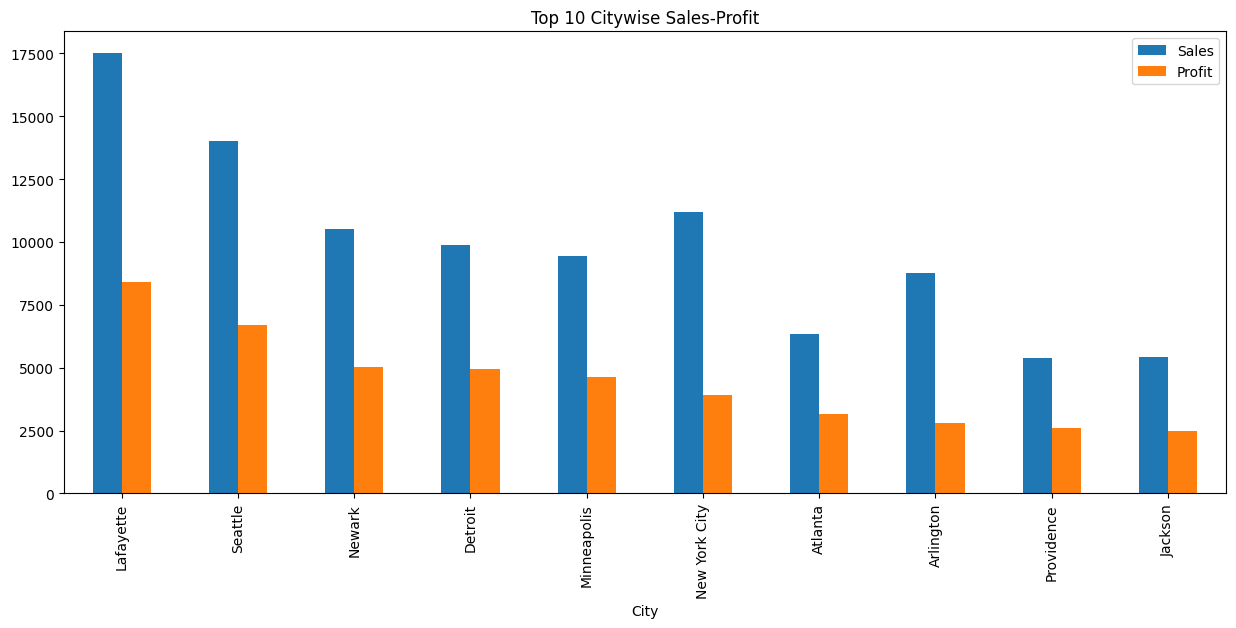

In [90]:
df[["City", "Sales","Profit"]].sort_values(by="Profit", ascending=False).head(10).plot(x="City", kind="bar",figsize=(15,6))
plt.title("Top 10 Citywise Sales-Profit")
plt.show()

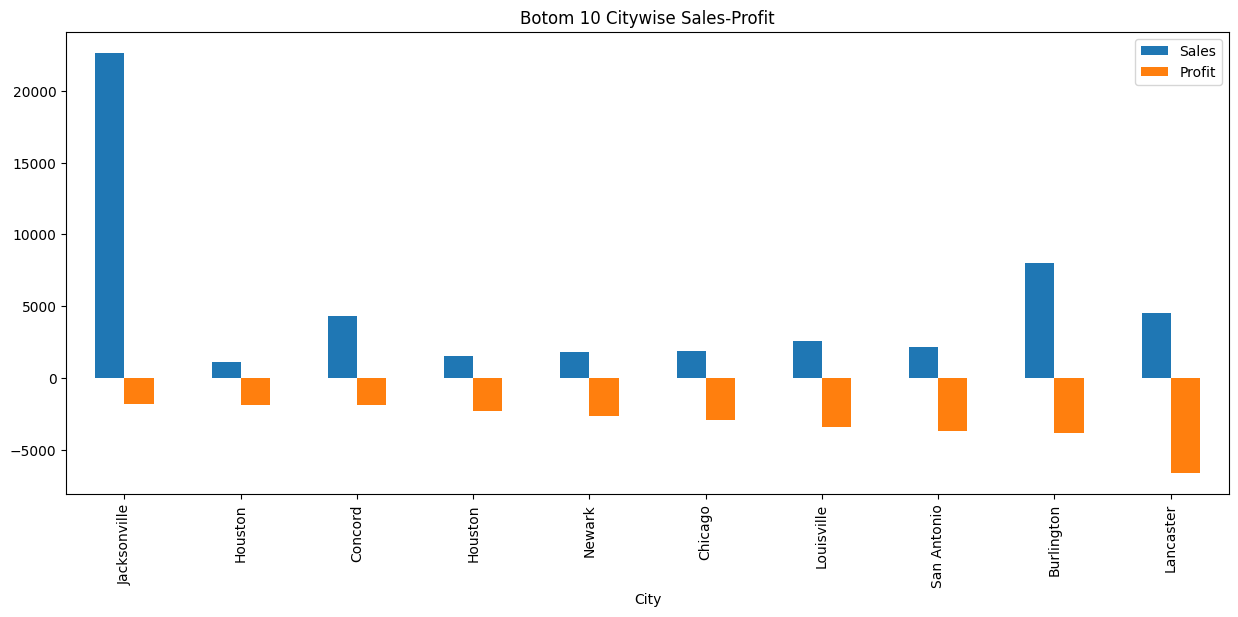

In [92]:
df[["City", "Sales","Profit"]].sort_values(by="Profit", ascending=False).tail(10).plot(x="City", kind="bar",figsize=(15,6))
plt.title("Botom 10 Citywise Sales-Profit")
plt.show()

In [94]:
df["Segment"].value_counts()

Segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64

In [99]:
segment=df.groupby("Segment")[["Sales","Quantity","Profit"]].sum()
segment.sort_values(by=["Sales"], ascending=False)

,Sales,Quantity,Profit
Segment,,,
Consumer,1.161401e+06,19521,134119.2092
Corporate,7.061464e+05,11608,91979.1340
Home Office,4.296531e+05,6744,60298.6785


Text(0.5, 1.0, 'Segment vs Category')

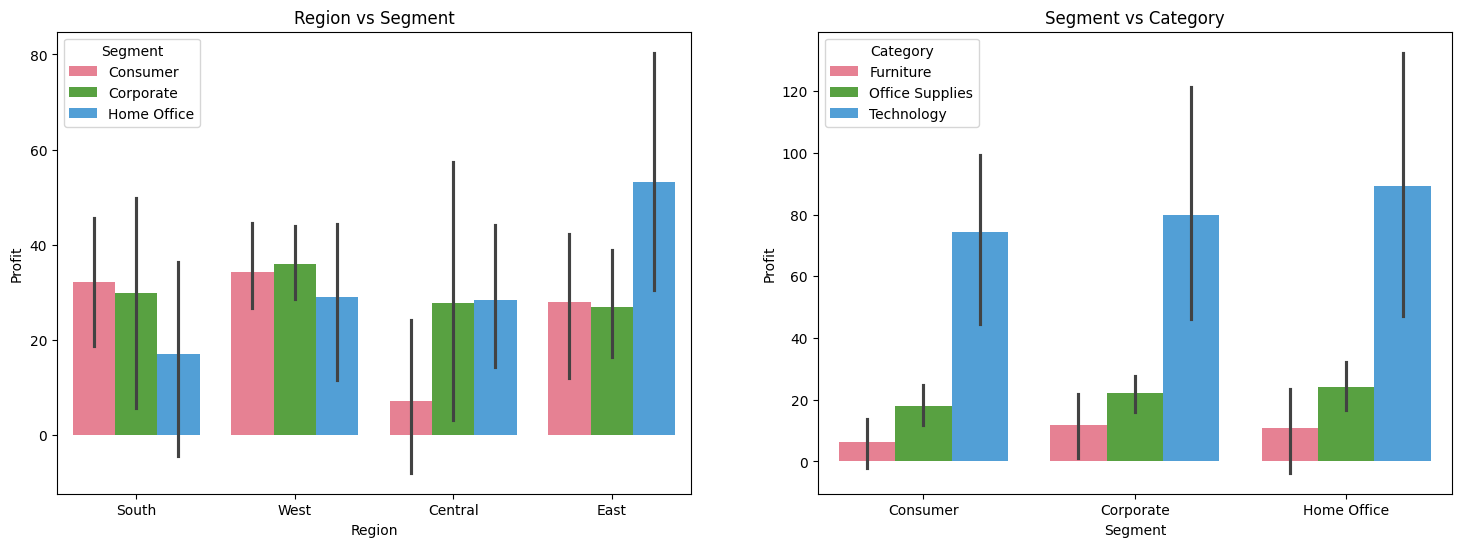

In [102]:
plt.figure(figsize=(18,6))

plt.subplot(1,2,1)
sns.barplot(x="Region",y="Profit",hue="Segment",data=df,palette='husl')
plt.title("Region vs Segment")

plt.subplot(1,2,2)
sns.barplot(x="Segment",y="Profit",hue="Category",data=df,palette="husl")
plt.title("Segment vs Category")

In [105]:
shipmode=df.groupby("Ship Mode")[["Sales","Quantity","Profit"]].sum()
shipmode.sort_values(by=["Sales"], ascending=False)

,Sales,Quantity,Profit
Ship Mode,,,
Standard Class,1.358216e+06,22797,164088.7875
Second Class,4.591936e+05,7423,57446.6354
First Class,3.514284e+05,5693,48969.8399
Same Day,1.283631e+05,1960,15891.7589


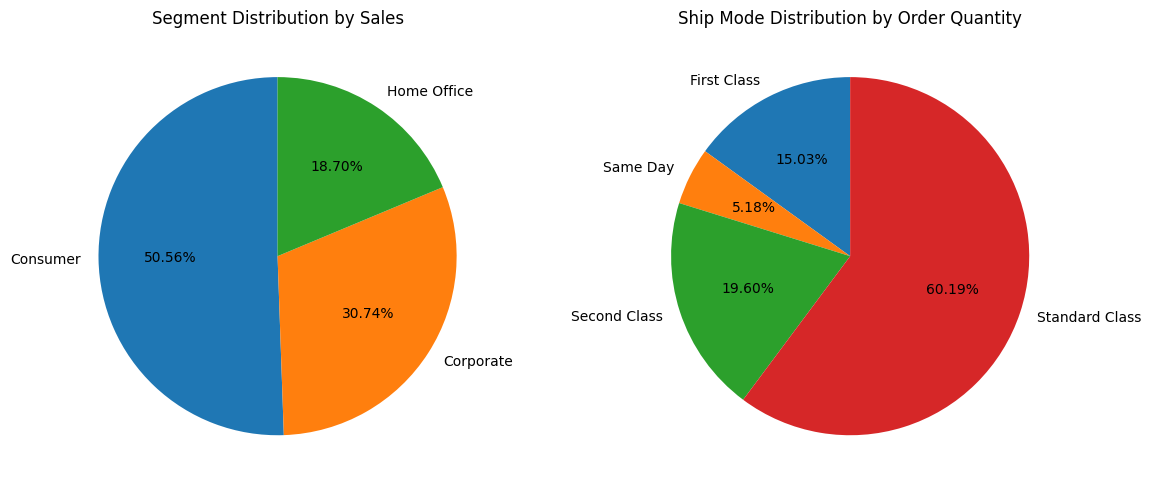

In [117]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.pie(segment['Sales'].values, labels=segment.index, startangle=90, autopct='%1.2f%%')
plt.title("Segment Distribution by Sales")

plt.subplot(1, 2, 2)
plt.pie(shipmode['Quantity'].values, labels=shipmode.index, startangle=90, autopct='%1.2f%%')
plt.title("Ship Mode Distribution by Order Quantity")

plt.tight_layout()
plt.show()

In [120]:
cat=df.groupby("Category")[["Sales","Profit"]].sum()
cat

,Sales,Profit
Category,,
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008
Technology,836154.0330,145454.9481


C:\Users\Vlad\AppData\Local\Temp\ipykernel_32292\928271565.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Category",y="Profit",data=df,palette="husl")


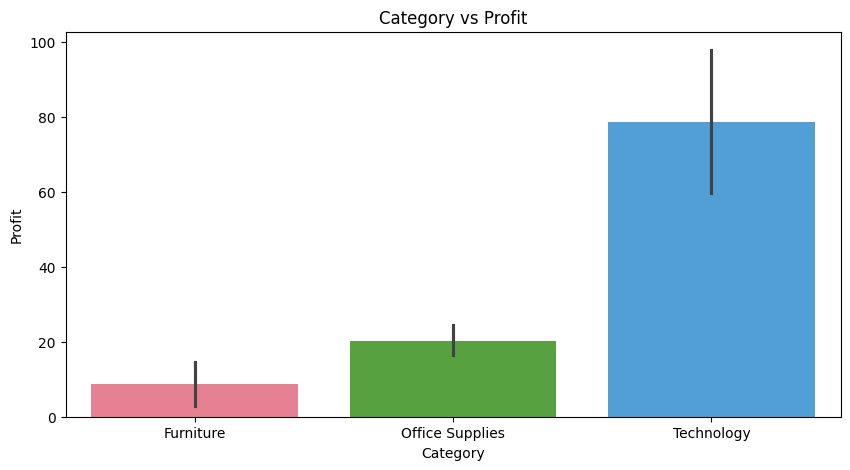

In [122]:
plt.figure(figsize=(10,5))
sns.barplot(x="Category",y="Profit",data=df,palette="husl")
plt.title("Category vs Profit")
plt.show()

In [126]:
sub_cat=df.groupby("Sub-Category")[["Sales","Profit"]].sum()
sub_cat["Profit Margin%"]=round((sub_cat["Profit"]/sub_cat["Sales"])*100,2)
sub_cat.sort_values(by=["Profit Margin%"],ascending=False)

,Sales,Profit,Profit Margin%
Sub-Category,,,
Labels,12486.3120,5546.2540,44.42
Paper,78479.2060,34053.5693,43.39
Envelopes,16476.4020,6964.1767,42.27
Copiers,149528.0300,55617.8249,37.20
Fasteners,3024.2800,949.5182,31.40
Accessories,167380.3180,41936.6357,25.05
Art,27118.7920,6527.7870,24.07
Appliances,107532.1610,18138.0054,16.87
Binders,203412.7330,30221.7633,14.86


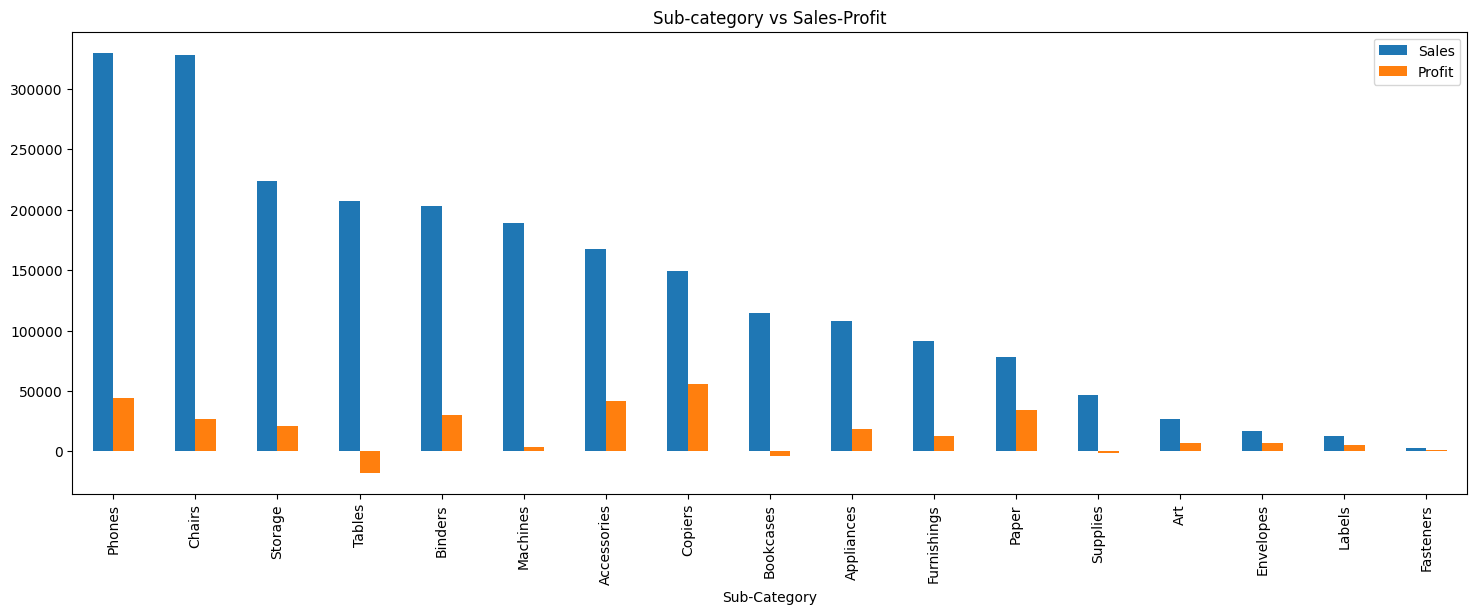

In [128]:
sub_cat[["Sales","Profit"]].sort_values(by=['Sales'],ascending=False).plot(kind='bar',figsize=(18,6))
plt.title("Sub-category vs Sales-Profit")
plt.show()

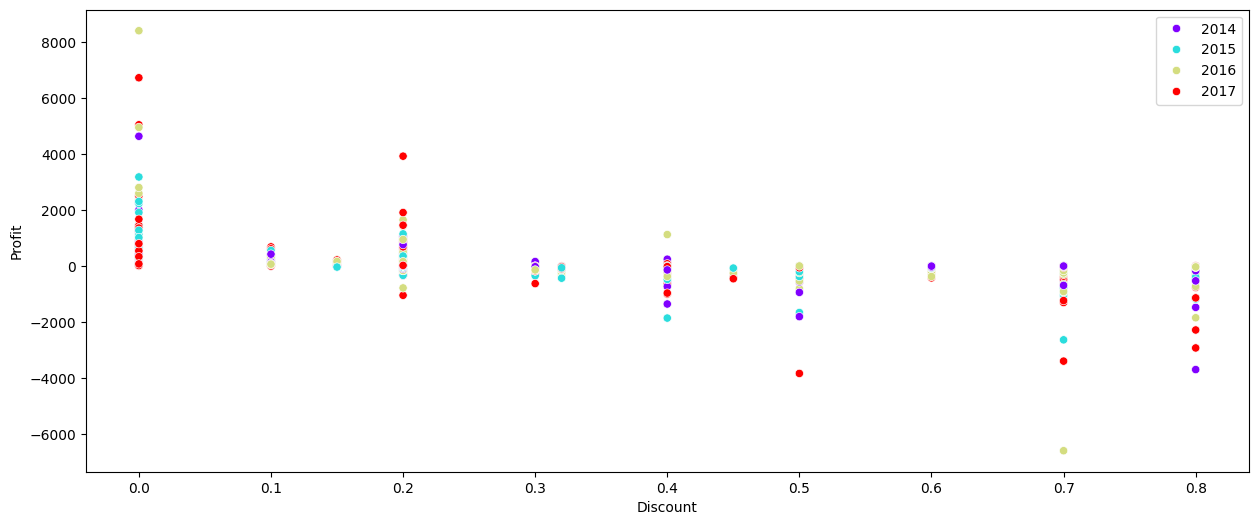

In [144]:
plt.figure(figsize=(15,6))
sns.scatterplot(x="Discount",y="Profit",hue='Year',data=df,palette="rainbow")
plt.legend()
plt.show()

C:\Users\Vlad\AppData\Local\Temp\ipykernel_32292\727993153.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="Sub-Category",x="Profit",data=df,palette="husl")


Text(0.5, 1.0, 'Profit vs Sub-Category')

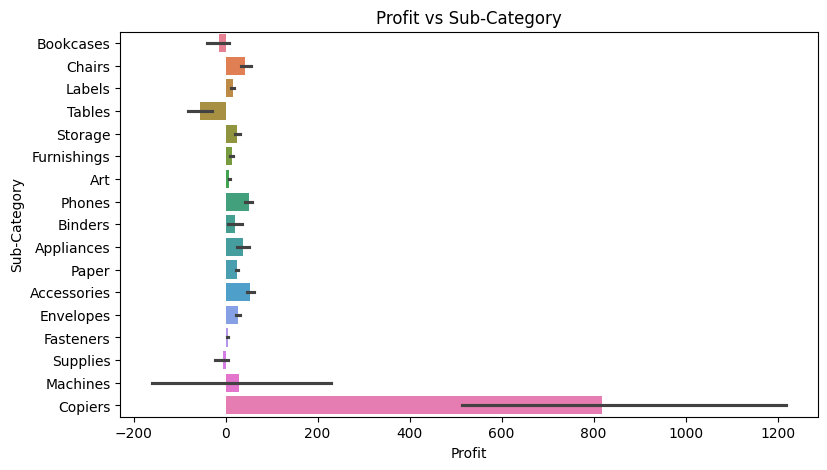

In [142]:

plt.figure(figsize=(9, 5))
sns.barplot(y="Sub-Category",x="Profit",data=df,palette="husl")
plt.title('Profit vs Sub-Category')


C:\Users\Vlad\AppData\Local\Temp\ipykernel_32292\578833423.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="Sub-Category",x="Profit",data=df,palette="husl")
C:\Users\Vlad\AppData\Local\Temp\ipykernel_32292\578833423.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="Sub-Category",x="Discount",data=df,palette="husl")


Text(0.5, 1.0, 'Discount vs Subcategory')

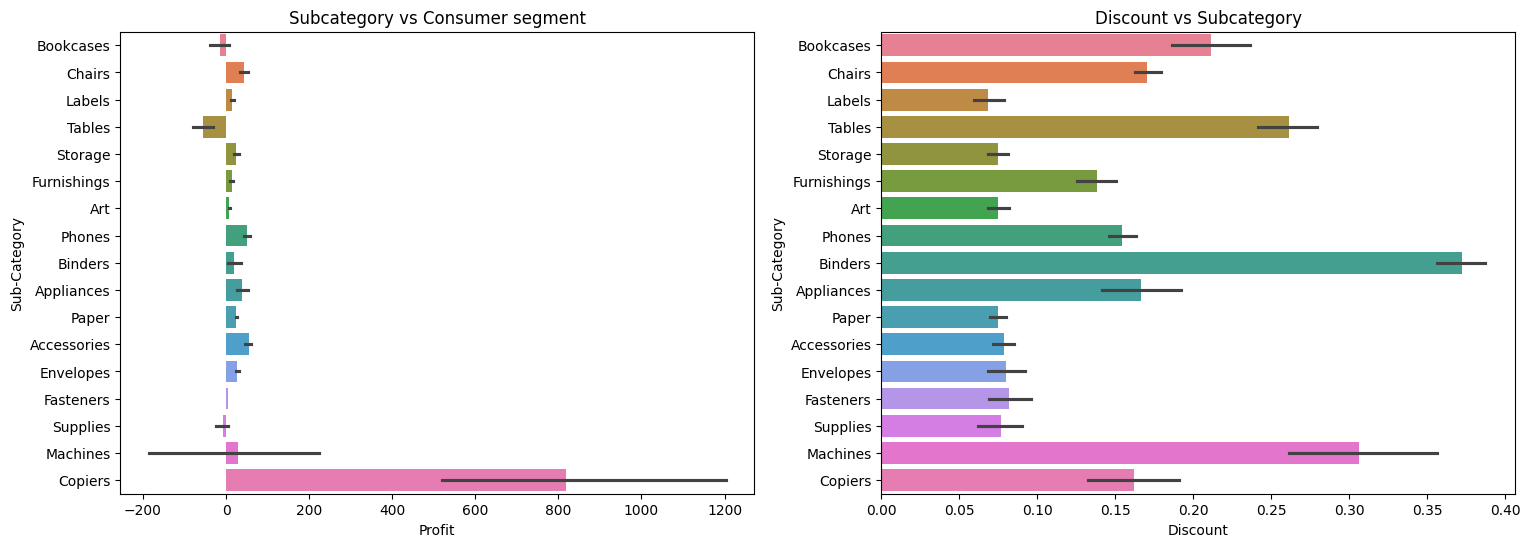

In [141]:
plt.figure(figsize=(18,6))

plt.subplot(1,2,1)
sns.barplot(y="Sub-Category",x="Profit",data=df,palette="husl")
plt.title("Subcategory vs Consumer segment")

plt.subplot(1,2,2)
sns.barplot(y="Sub-Category",x="Discount",data=df,palette="husl")
plt.title("Discount vs Subcategory")

# Conclusion

- The main reason which leads to loss is discounts .Some stores are in loss because they are giving more discounts over profitibity range which results in low profit margins and some stores due to low sales as customers are not ordering from this stores as prices are higher or fewer discount option available on products.


- There is continuous increase in sales from 2014-2017 for each USA region market except South as its sales decrease from 2014 and then again increase upto 2017.


- Some cities have very less sales. Lack of awareness can be the reason for it.So advertising in those cities will lead to increase in sales and profit.


- Homeoffice segment performs well in most region but consumer and corporate segment needs focus as these two having low profit.


- Technology category perfoms well(highest profit) in each segment followed by furniture but office supplies need focus as its having lowest profit in each segment.


- Tables,labels,fastners are subcategory which are having lowest profit in consumer segment.Main reason of this tables section giving highest discount over the profitabilty range which result in negative profit margin.


- Superstore makes highest profit in Copiers,Phones, Bookcases subcategories as discounts on these are in profitable margin also sales from these subcategories is quite good.


- Tables,Chairs,Binders this are subcategories which giving high discounts over profit range hence they are having least profit margin though sales are good.
    